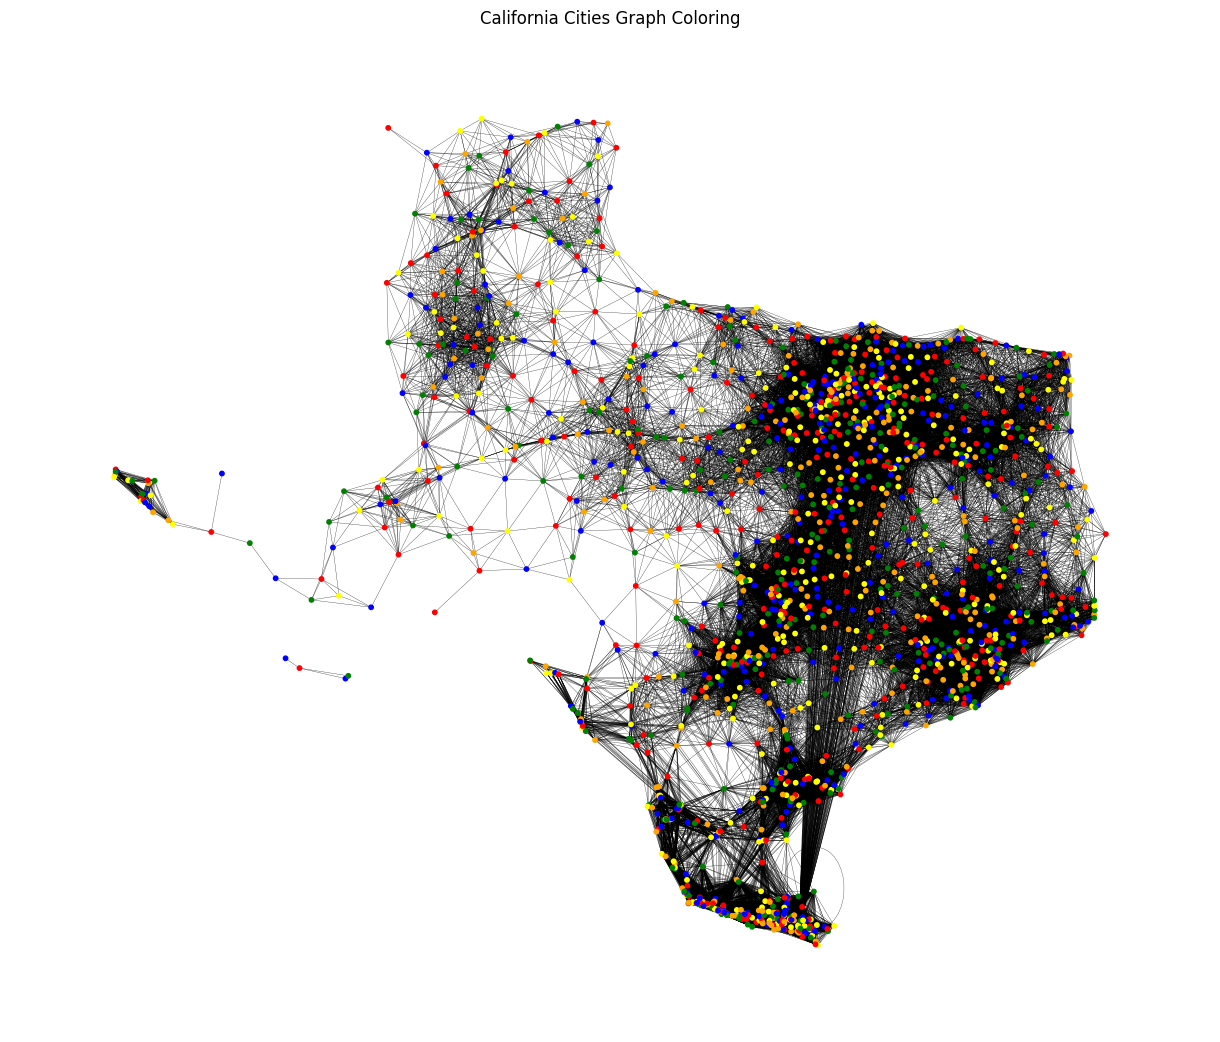

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math

# Load dataset
data = pd.read_csv("uscities.csv")

# Filter California cities
ca = data[data["state_id"]=="TX"]

# Take city name + coordinates
cities = ca[["city","lat","lng"]].reset_index(drop=True)

G = nx.Graph()

# Add nodes
for i,row in cities.iterrows():
    G.add_node(row["city"], pos=(row["lng"],row["lat"]))

# Distance function
def distance(x1,y1,x2,y2):
    return math.sqrt((x1-x2)**2 + (y1-y2)**2)

# Connect nearby cities (distance threshold)
for i in range(len(cities)):
    for j in range(i+1,len(cities)):

        d = distance(
            cities.iloc[i]["lat"],
            cities.iloc[i]["lng"],
            cities.iloc[j]["lat"],
            cities.iloc[j]["lng"]
        )

        # Connect if close
        if d < 0.8:
            G.add_edge(
                cities.iloc[i]["city"],
                cities.iloc[j]["city"]
            )

# Graph coloring
colors = nx.coloring.greedy_color(G)

color_list = ["red","blue","green","yellow","orange"]

node_colors = [
color_list[colors[node] % len(color_list)]
for node in G.nodes()
]

# Get positions
pos = nx.get_node_attributes(G,'pos')

plt.figure(figsize=(12,10))

nx.draw(G,
        pos,
        node_size=10,
        node_color=node_colors,
        with_labels=False,
        width=0.2)

plt.title("California Cities Graph Coloring")

plt.show()

In [ ]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()
a = model.NewIntVar(1, 3, 'x')
b = model.NewIntVar(1, 3, 'y')
c = model.NewIntVar(1, 3, 'z')

model.Add(a != b)
model.Add(b != c)
model.Add(c != a)

solver = cp_model.CpSolver()
solution_printer = cp_model.VarArraySolutionPrinter([a, b, c])
solver.parameters.enumerate_all_solutions = True
solver.Solve(model, solution_printer)

print('optimal', cp_model.OPTIMAL)
print('Feasable', cp_model.FEASIBLE)
print('InFeasable', cp_model.INFEASIBLE)
print('Unknown', cp_model.UNKNOWN)

# cp_model :
# CpModel
# CpSolver 




Solution 0, time = 0.00 s
  x = 1   y = 2   z = 3 
Solution 1, time = 0.00 s
  x = 2   y = 1   z = 3 
Solution 2, time = 0.00 s
  x = 1   y = 3   z = 2 
Solution 3, time = 0.00 s
  x = 2   y = 3   z = 1 
Solution 4, time = 0.01 s
  x = 3   y = 1   z = 2 
Solution 5, time = 0.01 s
  x = 3   y = 2   z = 1 
optimal CpSolverStatus.OPTIMAL
Feasable CpSolverStatus.FEASIBLE
InFeasable CpSolverStatus.INFEASIBLE
Unknown CpSolverStatus.UNKNOWN
